In [1]:
%config InlineBackend.figure_format = 'retina'
from wealth_process_V_opt import *
from optim import *
from decimal import *
import pandas as pd
import seaborn as sns   
import warnings
import time

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# One miner and several pps pool

In [2]:
Lam ,b = 6, 3.125 # block discovery rate of the network and reward for finding a block
H = 1 # Total hashpower of the netwwork
h = 0.1
c = h * Lam * b / 1.2  # operational cost per time unit (profitability on average)
X_solo = wealth_process(h * Lam, b, c, 0, 1) # Define the wealth process for a solo miner
# PPS pools
fs = np.array([0.005, 0.01, 0.03])  # pool fees
deltas = np.array([0.7, 0.3, 0.1])  # difficulty reduction
lams= Lam * h / deltas # arrival rates of the pools
bs = b * (1 - fs) * deltas  # rewards after pool fees
X_pps = [wealth_process(lam, b, c, 0, 1 ) for lam, b in zip(lams, bs)] # Define the wealth

beta = 0.5  # Define the ruin probability threshold
x = sc.optimize.root_scalar(lambda x: X_solo.ruin_proba(x) - beta, bracket=[0.01, 1000], method='bisect').root # initial wealth of the miner
print(x)

# Compute the expected value of the wealth process at time T=1
# X_solo_1.E(x), X_solo_1.Var()
q = 0.03 # Define the discount rate
# X_solo_1.V(x,q)[1]

div_pps = [X.V(x, q)[1] for X in X_pps]
# print("Expected values of the wealth process when solo mining:", X_solo.E(x))
# print("Expected values of the wealth process when pps mining:", [X.E(x) for X in X_pps])
# print("Variance of the wealth process when solo mining:", X_solo.Var() )

# print("Variance of the wealth process when pps mining:", [X.Var() for X in X_pps])
# print("Expected discounted dividend when solo mining:", X_solo.V(x, q)[1] )
# print("Expected discounted dividend when pps mining:", div_pps)

rows = [{
    "pool": "solo",
    "fee": 0.0,
    "difficulty reduction": 1.0,
    "reward arrival rate": h * Lam,
    "reward size": b,
    "expected discounted dividend": X_solo.V(x, q)[1],
}]

rows += [{
    "pool": f"PPS #{i+1}",
    "fee": float(fs[i]),
    "difficulty reduction": float(deltas[i]),
    "reward arrival rate": float(lams[i]),
    "reward size": float(bs[i]),
    "expected discounted dividend": float(div_pps[i]),
} for i in range(len(fs))]
df_characteristics = pd.DataFrame(rows)[["pool", "fee", "difficulty reduction"]].copy()
df_characteristics.columns = ["Pool", "Management Fee", "Difficulty Reduction"]

df_rewards = pd.DataFrame(rows)[["pool", "reward arrival rate", "reward size", "expected discounted dividend"]].copy()
df_rewards.columns = ["Pool", "Reward Arrival Rate", "Reward Size", "Expected Discounted Dividend"]

latex_table_1 = df_characteristics.to_latex(index=False, float_format="%.3f")
latex_table_2 = df_rewards.to_latex(index=False, float_format="%.3f")

print("Pool Characteristics:")
print(latex_table_1)
print("\nReward and Dividend:")
print(latex_table_2)


5.754161256505919
Pool Characteristics:
\begin{tabular}{lrr}
\toprule
Pool & Management Fee & Difficulty Reduction \\
\midrule
solo & 0.000 & 1.000 \\
PPS #1 & 0.005 & 0.700 \\
PPS #2 & 0.010 & 0.300 \\
PPS #3 & 0.030 & 0.100 \\
\bottomrule
\end{tabular}


Reward and Dividend:
\begin{tabular}{lrrr}
\toprule
Pool & Reward Arrival Rate & Reward Size & Expected Discounted Dividend \\
\midrule
solo & 0.600 & 3.125 & 7.891 \\
PPS #1 & 0.857 & 2.177 & 8.250 \\
PPS #2 & 2.000 & 0.928 & 9.552 \\
PPS #3 & 6.000 & 0.303 & 10.578 \\
\bottomrule
\end{tabular}



# Combining two pools? 

In [20]:
fs = np.array([0, 0.005, 0.01, 0.03])  # pool fees
deltas = np.array([1, 0.7, 0.3, 0.1])  # difficulty reduction
lams= Lam * h / deltas # arrival rates of the pools
bs = b * (1 - fs) * deltas  # rewards after pool fees

prec = Decimal('0.001')  # precision for the position
res = {}
m_comb_max = 2
m = 3
for comb in itertools.combinations(range(m+1), m_comb_max):
    w = np.array([1 / 2, 1 / 2])
    X_mixed = wealth_process(lams[np.array(comb)], bs[np.array(comb)], c, 1, w)
    res_max_scalar = max_scalar(X_mixed, x, q)
    res_max_scalar['position'][res_max_scalar['position'] > 1 - prec] = 1
    res_max_scalar['position'][res_max_scalar['position'] < prec] = 0
    res[comb] = res_max_scalar
res
    

{(0, 1): {'position': array([0., 1.]), 'value': 8.250050206013865},
 (0, 2): {'position': array([0., 1.]), 'value': 9.551578168934803},
 (0, 3): {'position': array([0., 1.]), 'value': 10.57791579664647},
 (1, 2): {'position': array([0., 1.]), 'value': 9.551582008986149},
 (1, 3): {'position': array([0., 1.]), 'value': 10.577918565499656},
 (2, 3): {'position': array([0., 1.]), 'value': 10.577931372488557}}

# Adding One PPLNS pool

[0.85714286 2.         6.        ] [0.6        0.65454545 0.70909091 0.76363636 0.81818182 0.87272727
 0.92727273 0.98181818 1.03636364 1.09090909 1.14545455 1.2
 1.25454545 1.30909091 1.36363636 1.41818182 1.47272727 1.52727273
 1.58181818 1.63636364 1.69090909 1.74545455 1.8        1.85454545
 1.90909091 1.96363636 2.01818182 2.07272727 2.12727273 2.18181818
 2.23636364 2.29090909 2.34545455 2.4        2.45454545 2.50909091
 2.56363636 2.61818182 2.67272727 2.72727273 2.78181818 2.83636364
 2.89090909 2.94545455 3.         3.05454545 3.10909091 3.16363636
 3.21818182 3.27272727 3.32727273 3.38181818 3.43636364 3.49090909
 3.54545455 3.6        3.65454545 3.70909091 3.76363636 3.81818182
 3.87272727 3.92727273 3.98181818 4.03636364 4.09090909 4.14545455
 4.2        4.25454545 4.30909091 4.36363636 4.41818182 4.47272727
 4.52727273 4.58181818 4.63636364 4.69090909 4.74545455 4.8
 4.85454545 4.90909091 4.96363636 5.01818182 5.07272727 5.12727273
 5.18181818 5.23636364 5.29090909 5.34545

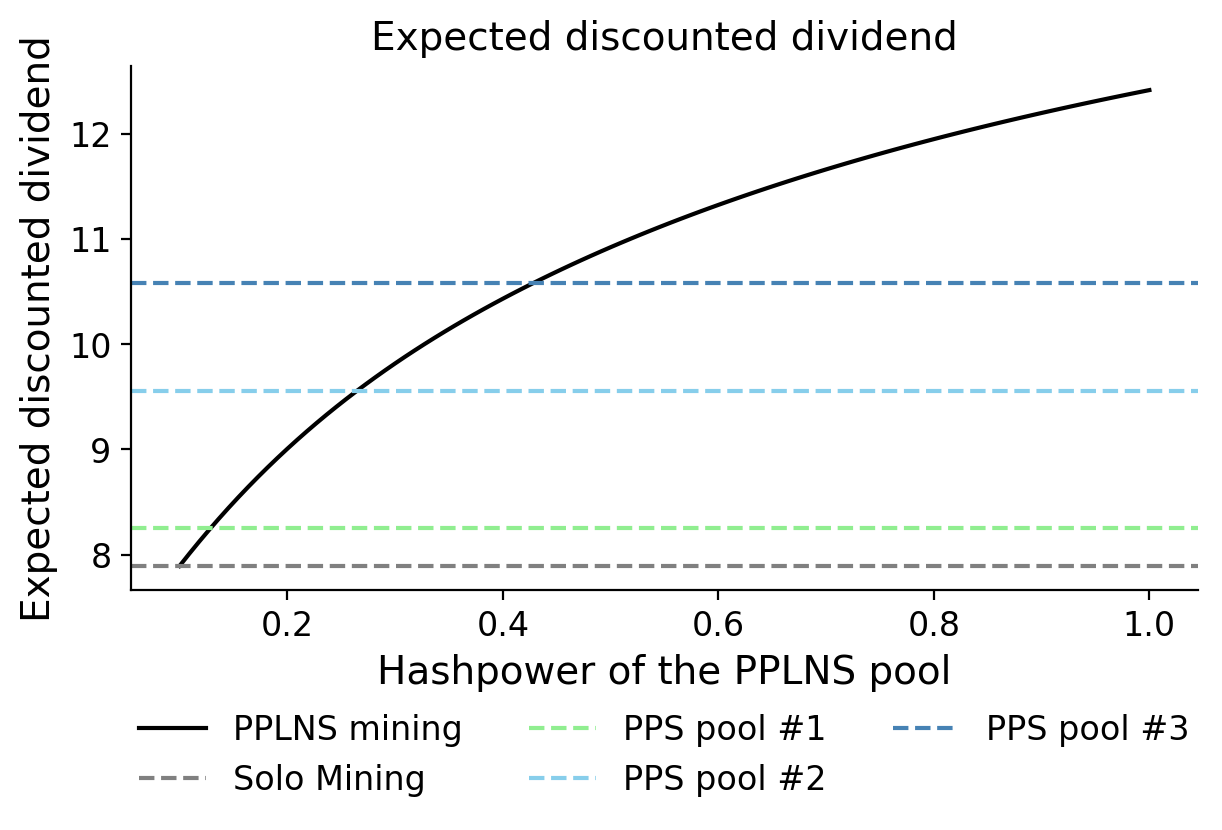

In [29]:
Lam ,b = 6, 3.125 # block discovery rate of the network and reward for finding a block
H = 1 # Total hashpower of the netwwork
h = 0.1
Hs_pplns = np.linspace(0, 1 - h, 100) # Hashpower of mining pool 1 (pplns)
c = h * Lam * b / 1.2  # operational cost per time unit (profitability on average)
X_solo = wealth_process(h * Lam, b, c, 0, 1) # Define the wealth process for a solo miner
f_pplns = 0.00 # Define the fee for PPLNS mining
X_pplns = [wealth_process((H_pplns + h) * Lam, h * b* (1- f_pplns) / (H_pplns + h), c, 0, 1) for H_pplns in Hs_pplns] # Define the wealth
# process for a PPLNS miner
fs = np.array([0.005, 0.01, 0.03])  # pool fees
deltas = np.array([0.7, 0.3, 0.1])  # difficulty reduction
lams= Lam * h / deltas # arrival rates of the pools
print(lams, (Hs_pplns + h) * Lam)

bs = b * (1 - fs) * deltas  # rewards after pool fees
print(bs, h * b* (1- f_pplns) / (Hs_pplns + h))

X_pps = [wealth_process(lam, b, c, 0, 1 ) for lam, b in zip(lams, bs)] # Define the wealth

beta = 0.5  # Define the ruin probability threshold
x = sc.optimize.root_scalar(lambda x: X_solo.ruin_proba(x) - beta, bracket=[0.01, 1000], method='bisect').root # initial wealth of the miner

# Compute the expected value of the wealth process at time T=1
# X_solo_1.E(x), X_solo_1.Var()
q = 0.03 # Define the discount rate
# X_solo_1.V(x,q)[1]
div_pplns = [X.V(x, q)[1] for X in X_pplns]
div_pps = [X.V(x, q)[1] for X in X_pps]
print("Expected values of the wealth process when solo mining:", X_solo.E(x))
print("Expected values of the wealth process when pplns mining:", [X.E(x) for X in X_pplns])
print("Expected values of the wealth process when pps mining:", [X.E(x) for X in X_pps])
print("Variance of the wealth process when solo mining:", X_solo.Var() )
print("Variance of the wealth process when pplns mining:", [X.Var() for X in X_pplns])
print("Variance of the wealth process when pps mining:", [X.Var() for X in X_pps])
print("Expected discounted dividend when solo mining:", X_solo.V(x, q)[1] )
print("Expected discounted dividend when pplns mining:", div_pplns)
print("Expected discounted dividend when pps mining:", div_pps)

palette = ["#808080", "#90EE90", "#87CEEB", "#4682B4"]

plt.plot(Hs_pplns + h, div_pplns, label="PPLNS mining", color="black")
plt.axhline(y=X_solo.V(x, q)[1], linestyle="--", label="Solo Mining", color=palette[0])

for i, pps in enumerate(div_pps):
    plt.axhline(y=pps, linestyle="--", label=f"PPS pool #{i+1}", color=palette[i+1])

plt.xlabel("Hashpower of the PPLNS pool", fontsize=14)
plt.ylabel("Expected discounted dividend", fontsize=14)
plt.title("Expected discounted dividend", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=3,
    frameon=False,
    fontsize=12
)

sns.despine()

plt.tight_layout(rect=(0, 0.08, 1, 1))
dropbox_path = Path("/Users/pgoffard/Dropbox/Collab/Albrecher-Fouque-Goffard/Figures")
# output_path = "../figures/pplns_dividend.pdf"
plt.gcf().savefig(dropbox_path / "pplns_dividend.pdf", bbox_inches="tight")
plt.show()

